In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import japanize_matplotlib
import arviz as az

In [2]:
df = pd.read_csv("../data/nigeria_malaria.csv")
print(df.shape)
df.head()

(25, 2)


,year,incidence_per_1000
0,2000,401.79
1,2001,394.49
2,2002,381.75
3,2003,382.09
4,2004,390.12


In [3]:
df_eq = df[df["year"] >= 2015].reset_index(drop=True)
print(df_eq.shape)
incidence_obs = df_eq["incidence_per_1000"].values
years = df_eq["year"]
n_years = len(incidence_obs)
N_pop = 1000.0

n_steps_per_year = 50
dt = 1.0 / n_steps_per_year

(10, 2)


In [4]:
with pm.Model() as sis_model_v0:
    gamma = pm.Gamma("gamma", alpha=4, beta=4/6)
    beta = pm.Gamma("beta", alpha=4, beta=4/9)

    I0 = pm.Deterministic("I0", incidence_obs[0]/gamma)

    def euler_step(I_prev, beta, gamma, N, dt):
        S_prev = N - I_prev
        dI = (beta * S_prev * I_prev / N - gamma * I_prev) * dt
        I_new = pt.clip(I_prev + dI, 0.0, N)
        return I_new

    total_steps = n_steps_per_year * (n_years - 1)

    I_path, _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[I0],
        non_sequences=[beta, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = pt.arange(n_steps_per_year - 1, total_steps, n_steps_per_year)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    incidence_pred = gamma * I_pred
    pm.Deterministic("incidence_pred", incidence_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=3, beta=3/30)
    rate_param = pm.Deterministic("rate_params", alpha_conc / pt.clip(incidence_pred, 1.0, N_pop))

    pm.Gamma("obs", alpha=alpha_conc, beta=rate_param, observed=incidence_obs)

    
        
        

/tmp/ipykernel_109524/635395664.py:15: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  I_path, _ = pytensor.scan(


/home/manaty/baysian-epidemiological-models/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2978: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


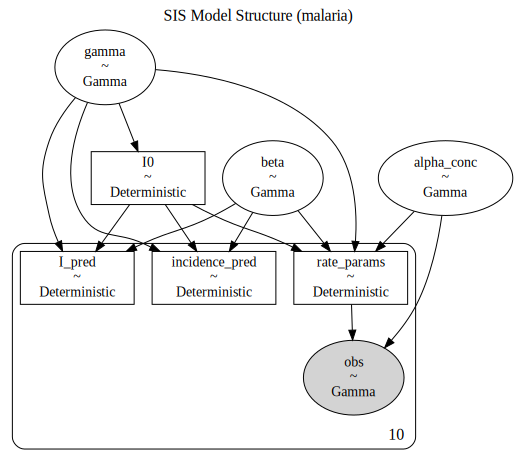

In [5]:
g_v0 = pm.model_to_graphviz(sis_model_v0)

g_v0.graph_attr.update(
    label="SIS Model Structure (malaria)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

# 3. 指定したファイル名で保存
g_v0.render(filename="../models/sis_model_graph", format="png", cleanup=True)
g_v0

In [6]:
with sis_model_v0:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [alpha_conc, beta, gamma, obs]


I0 の分布: min= 17.27614546002786 max= 400.98663093008776 中央値= 51.85893028093647
gamma の分布: min= 0.707779207854644 max= 16.427854272045607 平均= 6.031099568799329
beta の分布: min= 0.7680305201973567 max= 30.836812523382186 平均= 9.2694901640922

R0 = beta/gamma の分布:
  1を超える割合: 0.6933333333333334
  中央値: 1.5852776442720078

incidence_pred の統計:
  最小値: 9.42861563512961e-50
  最大値: 5258.207312779058
  99percentile: 4915.987436577713


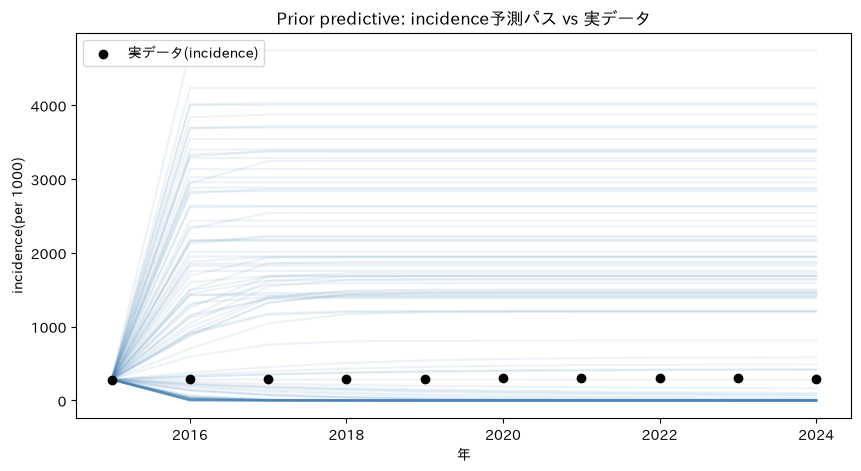

In [7]:
incidence_pred_prior = prior.prior["incidence_pred"].values.reshape(-1, n_years)
I0_prior = prior.prior["I0"].values.flatten()
gamma_prior = prior.prior["gamma"].values.flatten()
beta_prior = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(100):
    ax.plot(years, incidence_pred_prior[i], color="steelblue", alpha=0.1)
ax.scatter(years, incidence_obs, color="black", zorder=5, label="実データ(incidence)")
ax.set_xlabel("年"); ax.set_ylabel("incidence(per 1000)")
ax.legend()
ax.set_title("Prior predictive: incidence予測パス vs 実データ")
plt.savefig("../img/sis_prior_check_v0.png", dpi=100)

print("I0 の分布: min=", I0_prior.min(), "max=", I0_prior.max(), "中央値=", np.median(I0_prior))
print("gamma の分布: min=", gamma_prior.min(), "max=", gamma_prior.max(), "平均=", gamma_prior.mean())
print("beta の分布: min=", beta_prior.min(), "max=", beta_prior.max(), "平均=", beta_prior.mean())

R0_prior = beta_prior / gamma_prior
print("\nR0 = beta/gamma の分布:")
print("  1を超える割合:", (R0_prior > 1).mean())
print("  中央値:", np.median(R0_prior))

# --- 4. incidence予測値の数値的健全性 ---
print("\nincidence_pred の統計:")
print("  最小値:", incidence_pred_prior.min())
print("  最大値:", incidence_pred_prior.max())
print("  99percentile:", np.percentile(incidence_pred_prior, 99))

In [8]:
#N＝1000からN＝2e8にスケールアップ
df_eq = df[df["year"] >= 2015].reset_index(drop=True)
print(df_eq.shape)
N_pop = 2e8
incidence_obs = df_eq["incidence_per_1000"].values * N_pop / 1000
n_years = len(incidence_obs)

n_steps_per_year = 50
dt = 1.0 / n_steps_per_year

with pm.Model() as sis_model_v1:
    gamma = pm.Gamma("gamma", alpha=4, beta=4/6)
    beta = pm.Gamma("beta", alpha=4, beta=4/9)

    I0 = pm.Deterministic("I0", incidence_obs[0]/gamma)

    def euler_step(I_prev, beta, gamma, N, dt):
        S_prev = N - I_prev
        dI = (beta * S_prev * I_prev / N - gamma * I_prev) * dt
        I_new = pt.clip(I_prev + dI, 0.0, N)
        return I_new

    total_steps = n_steps_per_year * (n_years - 1)

    I_path, _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[I0],
        non_sequences=[beta, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = pt.arange(n_steps_per_year - 1, total_steps, n_steps_per_year)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    incidence_pred = gamma * I_pred
    pm.Deterministic("incidence_pred", incidence_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=3, beta=3/30)
    rate_param = pm.Deterministic("rate_params", alpha_conc / pt.clip(incidence_pred, 1.0, N_pop))

    pm.Gamma("obs", alpha=alpha_conc, beta=rate_param, observed=incidence_obs)

    
        
        

(10, 2)


/tmp/ipykernel_109524/1946032870.py:25: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  I_path, _ = pytensor.scan(


In [9]:
with sis_model_v1:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [alpha_conc, beta, gamma, obs]


I0 の分布: min= 3455229.092005572 max= 80197326.18601756 中央値= 10371786.056187294
gamma の分布: min= 0.707779207854644 max= 16.427854272045607 平均= 6.031099568799329
beta の分布: min= 0.7680305201973567 max= 30.836812523382186 平均= 9.2694901640922

R0 = beta/gamma の分布:
  1を超える割合: 0.6933333333333334
  中央値: 1.5852776442720078

incidence_pred の統計:
  最小値: 1.8857231270259249e-44
  最大値: 1051641462.5558116
  99percentile: 983197487.3155426


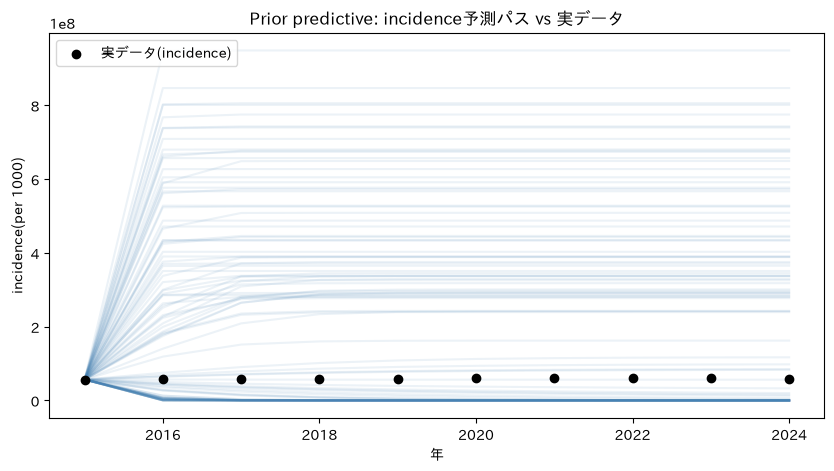

In [10]:
incidence_pred_prior = prior.prior["incidence_pred"].values.reshape(-1, n_years)
I0_prior = prior.prior["I0"].values.flatten()
gamma_prior = prior.prior["gamma"].values.flatten()
beta_prior = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(100):
    ax.plot(years, incidence_pred_prior[i], color="steelblue", alpha=0.1)
ax.scatter(years, incidence_obs, color="black", zorder=5, label="実データ(incidence)")
ax.set_xlabel("年"); ax.set_ylabel("incidence(per 1000)")
ax.legend()
ax.set_title("Prior predictive: incidence予測パス vs 実データ")
plt.savefig("../img/sis_prior_check_v1.png", dpi=100)

print("I0 の分布: min=", I0_prior.min(), "max=", I0_prior.max(), "中央値=", np.median(I0_prior))
print("gamma の分布: min=", gamma_prior.min(), "max=", gamma_prior.max(), "平均=", gamma_prior.mean())
print("beta の分布: min=", beta_prior.min(), "max=", beta_prior.max(), "平均=", beta_prior.mean())

R0_prior = beta_prior / gamma_prior
print("\nR0 = beta/gamma の分布:")
print("  1を超える割合:", (R0_prior > 1).mean())
print("  中央値:", np.median(R0_prior))

# --- 4. incidence予測値の数値的健全性 ---
print("\nincidence_pred の統計:")
print("  最小値:", incidence_pred_prior.min())
print("  最大値:", incidence_pred_prior.max())
print("  99percentile:", np.percentile(incidence_pred_prior, 99))

In [11]:
#gammaとbetaの事前分布の分散を5倍に縮小
df_eq = df[df["year"] >= 2015].reset_index(drop=True)
print(df_eq.shape)
N_pop = 2e8
incidence_obs = df_eq["incidence_per_1000"].values * N_pop / 1000
n_years = len(incidence_obs)

n_steps_per_year = 50
dt = 1.0 / n_steps_per_year

with pm.Model() as sis_model_v2:
    gamma = pm.Gamma("gamma", alpha=20, beta=20/6)
    beta = pm.Gamma("beta", alpha=20, beta=20/9)

    I0 = pm.Deterministic("I0", incidence_obs[0]/gamma)

    def euler_step(I_prev, beta, gamma, N, dt):
        S_prev = N - I_prev
        dI = (beta * S_prev * I_prev / N - gamma * I_prev) * dt
        I_new = pt.clip(I_prev + dI, 0.0, N)
        return I_new

    total_steps = n_steps_per_year * (n_years - 1)

    I_path, _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[I0],
        non_sequences=[beta, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = pt.arange(n_steps_per_year - 1, total_steps, n_steps_per_year)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    incidence_pred = gamma * I_pred
    pm.Deterministic("incidence_pred", incidence_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=3, beta=3/30)
    rate_param = pm.Deterministic("rate_params", alpha_conc / pt.clip(incidence_pred, 1.0, N_pop))

    pm.Gamma("obs", alpha=alpha_conc, beta=rate_param, observed=incidence_obs)

    
        
        

(10, 2)


/tmp/ipykernel_109524/2039761806.py:25: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  I_path, _ = pytensor.scan(


In [12]:
with sis_model_v2:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [alpha_conc, beta, gamma, obs]


I0 の分布: min= 5708357.497474934 max= 28987466.62111988 中央値= 9641334.568107113
gamma の分布: min= 1.958156631688675 max= 9.943665936323788 平均= 6.003006617997151
beta の分布: min= 3.9451561560397814 max= 16.80497683593273 平均= 9.10126902125386

R0 = beta/gamma の分布:
  1を超える割合: 0.89
  中央値: 1.5547289057329436

incidence_pred の統計:
  最小値: 2.2262939408240657e-12
  最大値: 794679179.4665538
  99percentile: 671410634.3290195


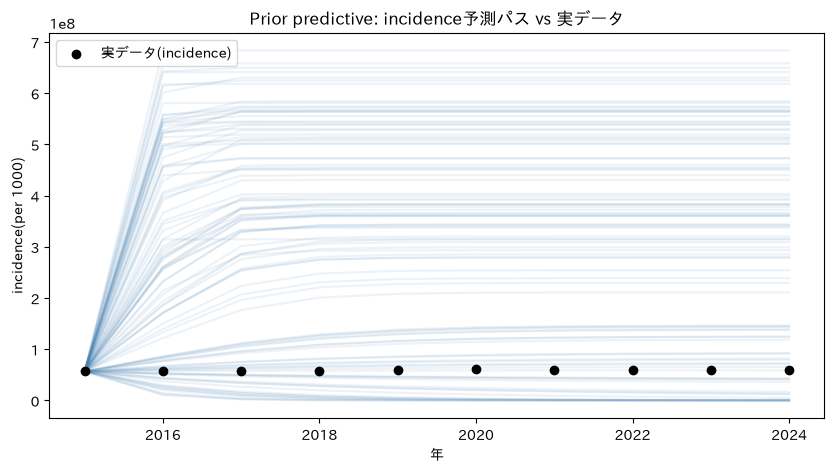

In [13]:
incidence_pred_prior = prior.prior["incidence_pred"].values.reshape(-1, n_years)
I0_prior = prior.prior["I0"].values.flatten()
gamma_prior = prior.prior["gamma"].values.flatten()
beta_prior = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(100):
    ax.plot(years, incidence_pred_prior[i], color="steelblue", alpha=0.1)
ax.scatter(years, incidence_obs, color="black", zorder=5, label="実データ(incidence)")
ax.set_xlabel("年"); ax.set_ylabel("incidence(per 1000)")
ax.legend()
ax.set_title("Prior predictive: incidence予測パス vs 実データ")
plt.savefig("../img/sis_prior_check_v2.png", dpi=100)

print("I0 の分布: min=", I0_prior.min(), "max=", I0_prior.max(), "中央値=", np.median(I0_prior))
print("gamma の分布: min=", gamma_prior.min(), "max=", gamma_prior.max(), "平均=", gamma_prior.mean())
print("beta の分布: min=", beta_prior.min(), "max=", beta_prior.max(), "平均=", beta_prior.mean())

R0_prior = beta_prior / gamma_prior
print("\nR0 = beta/gamma の分布:")
print("  1を超える割合:", (R0_prior > 1).mean())
print("  中央値:", np.median(R0_prior))

# --- 4. incidence予測値の数値的健全性 ---
print("\nincidence_pred の統計:")
print("  最小値:", incidence_pred_prior.min())
print("  最大値:", incidence_pred_prior.max())
print("  99percentile:", np.percentile(incidence_pred_prior, 99))

In [14]:
#基本再生産数R0を直接モデル化し,betaとgammaを比例関係でモデリングする
df_eq = df[df["year"] >= 2015].reset_index(drop=True)
print(df_eq.shape)
N_pop = 1000
incidence_obs = df_eq["incidence_per_1000"].values
n_years = len(incidence_obs)

n_steps_per_year = 50
dt = 1.0 / n_steps_per_year

with pm.Model() as sis_model_v3:
    gamma = pm.Gamma("gamma", alpha=20, beta=20/6)
    epsilon = pm.Gamma("epsilon", alpha=100, beta=100/0.05)
    R0 = pm.Deterministic("R0", 1 + epsilon)
    
    beta = pm.Deterministic("beta", gamma * R0)

    I0 = pm.Deterministic("I0", incidence_obs[0]/gamma)

    def euler_step(I_prev, beta, gamma, N, dt):
        S_prev = N - I_prev
        dI = (beta * S_prev * I_prev / N - gamma * I_prev) * dt
        I_new = pt.clip(I_prev + dI, 0.0, N)
        return I_new

    total_steps = n_steps_per_year * (n_years - 1)

    I_path, _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[I0],
        non_sequences=[beta, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = pt.arange(n_steps_per_year - 1, total_steps, n_steps_per_year)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    incidence_pred = gamma * I_pred
    pm.Deterministic("incidence_pred", incidence_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=3, beta=3/30)
    rate_param = pm.Deterministic("rate_params", alpha_conc / pt.clip(incidence_pred, 1.0, N_pop))

    pm.Gamma("obs", alpha=alpha_conc, beta=rate_param, observed=incidence_obs)

    
        
        

(10, 2)


/tmp/ipykernel_109524/486114868.py:28: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  I_path, _ = pytensor.scan(


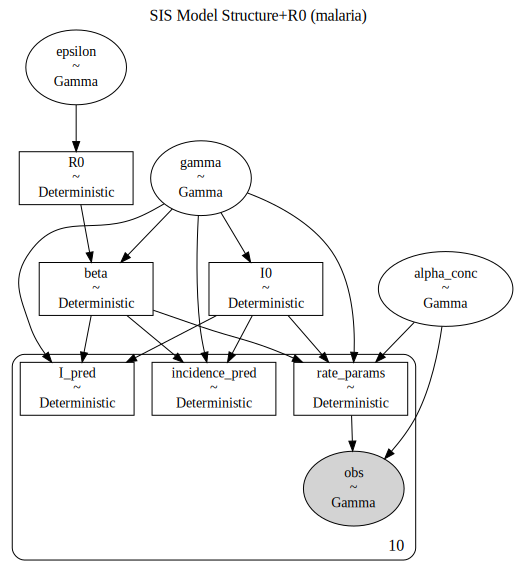

In [15]:
g_v3 = pm.model_to_graphviz(sis_model_v3)

g_v3.graph_attr.update(
    label="SIS Model Structure+R0 (malaria)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

# 3. 指定したファイル名で保存
g_v3.render(filename="../models/sis_model_graph_R0", format="png", cleanup=True)
g_v3

In [16]:
with sis_model_v3:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [alpha_conc, epsilon, gamma, obs]


I0 の分布: min= 28.54178748737467 max= 144.9373331055994 中央値= 48.20667284053556
gamma の分布: min= 1.958156631688675 max= 9.943665936323788 平均= 6.003006617997151
beta の分布: min= 2.0611030955464105 max= 10.476332265168852 平均= 6.304288900947633

R0 = beta/gamma の分布:
  1を超える割合: 1.0
  中央値: 1.0498619198964994

incidence_pred の統計:
  最小値: 131.95968379888177
  最大値: 502.3957852793221
  99percentile: 437.17713586652343


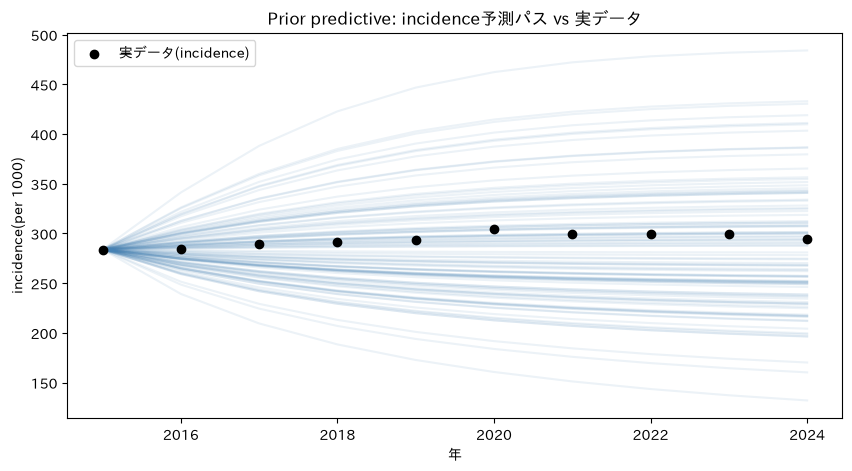

In [17]:
incidence_pred_prior = prior.prior["incidence_pred"].values.reshape(-1, n_years)
I0_prior = prior.prior["I0"].values.flatten()
gamma_prior = prior.prior["gamma"].values.flatten()
beta_prior = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(100):
    ax.plot(years, incidence_pred_prior[i], color="steelblue", alpha=0.1)
ax.scatter(years, incidence_obs, color="black", zorder=5, label="実データ(incidence)")
ax.set_xlabel("年"); ax.set_ylabel("incidence(per 1000)")
ax.legend()
ax.set_title("Prior predictive: incidence予測パス vs 実データ")
plt.savefig("../img/sis_prior_check_v3.png", dpi=100)

print("I0 の分布: min=", I0_prior.min(), "max=", I0_prior.max(), "中央値=", np.median(I0_prior))
print("gamma の分布: min=", gamma_prior.min(), "max=", gamma_prior.max(), "平均=", gamma_prior.mean())
print("beta の分布: min=", beta_prior.min(), "max=", beta_prior.max(), "平均=", beta_prior.mean())

R0_prior = beta_prior / gamma_prior
print("\nR0 = beta/gamma の分布:")
print("  1を超える割合:", (R0_prior > 1).mean())
print("  中央値:", np.median(R0_prior))

# --- 4. incidence予測値の数値的健全性 ---
print("\nincidence_pred の統計:")
print("  最小値:", incidence_pred_prior.min())
print("  最大値:", incidence_pred_prior.max())
print("  99percentile:", np.percentile(incidence_pred_prior, 99))

In [18]:
with sis_model_v3:
    idata = pm.sample(draws=2000, tune=2000, chains=4,cores=4,
                      target_accept=0.95, random_seed=42)
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=["beta", "gamma", "R0"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [gamma, epsilon, alpha_conc]


/home/manaty/baysian-epidemiological-models/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 19 seconds.


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,6.58,0.62,5.6,7.6,2916,3709,1.00,0.011,0.0085
gamma,6.27,0.61,5.3,7.3,2885,3660,1.00,0.011,0.0084
R0,1.0505,0.0046,1,1.1,2832,3564,1.00,8.6e-05,6.3e-05


In [19]:
#強い事前分布ではなく、弱情報事前分布でデータの支持を受けているかを確認
df_eq = df[df["year"] >= 2015].reset_index(drop=True)
print(df_eq.shape)
N_pop = 1000
incidence_obs = df_eq["incidence_per_1000"].values
n_years = len(incidence_obs)

n_steps_per_year = 50
dt = 1.0 / n_steps_per_year

with pm.Model() as sis_model_v4:
    gamma = pm.Gamma("gamma", alpha=20, beta=20/6)
    epsilon = pm.Gamma("epsilon", alpha=6.25, beta=6.25/0.05)
    R0 = pm.Deterministic("R0", 1 + epsilon)
    
    beta = pm.Deterministic("beta", gamma * R0)

    I0 = pm.Deterministic("I0", incidence_obs[0]/gamma)

    def euler_step(I_prev, beta, gamma, N, dt):
        S_prev = N - I_prev
        dI = (beta * S_prev * I_prev / N - gamma * I_prev) * dt
        I_new = pt.clip(I_prev + dI, 0.0, N)
        return I_new

    total_steps = n_steps_per_year * (n_years - 1)

    I_path, _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[I0],
        non_sequences=[beta, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = pt.arange(n_steps_per_year - 1, total_steps, n_steps_per_year)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    incidence_pred = gamma * I_pred
    pm.Deterministic("incidence_pred", incidence_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=3, beta=3/30)
    rate_param = pm.Deterministic("rate_params", alpha_conc / pt.clip(incidence_pred, 1.0, N_pop))

    pm.Gamma("obs", alpha=alpha_conc, beta=rate_param, observed=incidence_obs)

    
        
        

(10, 2)


/tmp/ipykernel_109524/2541488117.py:28: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  I_path, _ = pytensor.scan(


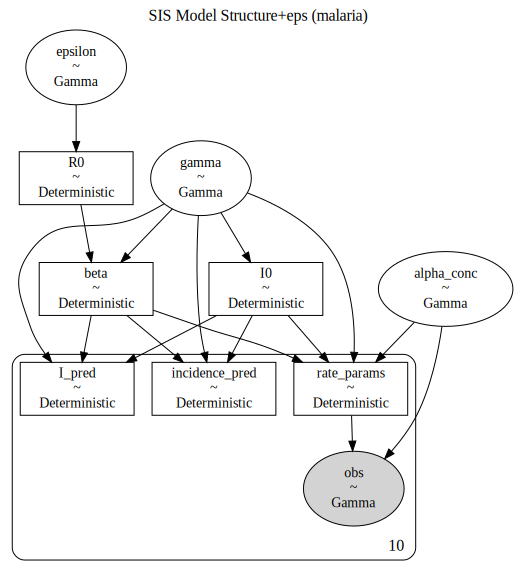

In [20]:
g_v4 = pm.model_to_graphviz(sis_model_v4)

g_v4.graph_attr.update(
    label="SIS Model Structure+eps (malaria)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

# 3. 指定したファイル名で保存
g_v4.render(filename="../models/sis_model_graph_eps", format="png", cleanup=True)
g_v4

In [21]:
with sis_model_v4:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [alpha_conc, epsilon, gamma, obs]


I0 の分布: min= 28.54178748737467 max= 144.9373331055994 中央値= 48.20667284053556
gamma の分布: min= 1.958156631688675 max= 9.943665936323788 平均= 6.003006617997151
beta の分布: min= 2.0729405027165715 max= 10.570260117082535 平均= 6.307935964303136

R0 = beta/gamma の分布:
  1を超える割合: 1.0
  中央値: 1.0472367716565918

incidence_pred の統計:
  最小値: 96.27221484092023
  最大値: 796.3592226863251
  99percentile: 628.4756401705358


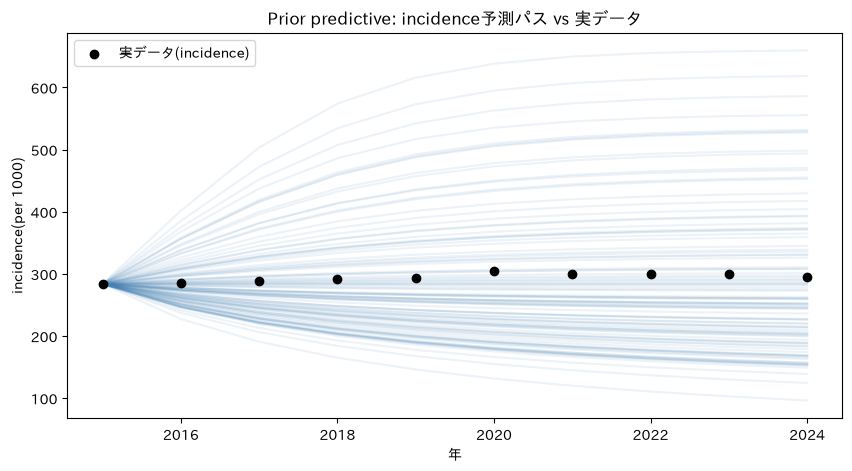

In [22]:
incidence_pred_prior = prior.prior["incidence_pred"].values.reshape(-1, n_years)
I0_prior = prior.prior["I0"].values.flatten()
gamma_prior = prior.prior["gamma"].values.flatten()
beta_prior = prior.prior["beta"].values.flatten()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(100):
    ax.plot(years, incidence_pred_prior[i], color="steelblue", alpha=0.1)
ax.scatter(years, incidence_obs, color="black", zorder=5, label="実データ(incidence)")
ax.set_xlabel("年"); ax.set_ylabel("incidence(per 1000)")
ax.legend()
ax.set_title("Prior predictive: incidence予測パス vs 実データ")
plt.savefig("../img/sis_prior_check_v4.png", dpi=100)

print("I0 の分布: min=", I0_prior.min(), "max=", I0_prior.max(), "中央値=", np.median(I0_prior))
print("gamma の分布: min=", gamma_prior.min(), "max=", gamma_prior.max(), "平均=", gamma_prior.mean())
print("beta の分布: min=", beta_prior.min(), "max=", beta_prior.max(), "平均=", beta_prior.mean())

R0_prior = beta_prior / gamma_prior
print("\nR0 = beta/gamma の分布:")
print("  1を超える割合:", (R0_prior > 1).mean())
print("  中央値:", np.median(R0_prior))

# --- 4. incidence予測値の数値的健全性 ---
print("\nincidence_pred の統計:")
print("  最小値:", incidence_pred_prior.min())
print("  最大値:", incidence_pred_prior.max())
print("  99percentile:", np.percentile(incidence_pred_prior, 99))

In [23]:
with sis_model_v4:
    idata = pm.sample(draws=2000, tune=2000, chains=4,cores=4,
                      target_accept=0.95, random_seed=42)
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=["beta", "gamma", "R0"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [gamma, epsilon, alpha_conc]


/home/manaty/baysian-epidemiological-models/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 31 seconds.


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,6.42,1.14,4.7,8.4,2387,3088,1.00,0.023,0.018
gamma,6.11,1.14,4.4,8.1,2378,3095,1.00,0.023,0.018
R0,1.0535,0.0109,1,1.1,2384,3038,1.00,0.00022,0.0002


# ナイジェリア マラリア罹患率(2015-2024) SIS機構モデル セッションサマリー

## 目的

SIRモデル(Eyamペスト)に続く機構論的モデルの第2弾として、**免疫を獲得しない(再感染しうる)感染症**を表現するSISモデルに取り組む。「地方病的平衡(endemic equilibrium)」という、SIRにはない新しい定性的挙動を扱う。

## データ取得の紆余曲折

- 当初提案したマラリア週次データ(モザンビーク Chimoio、論文中の図としてのみ存在)、CDC淋病データ、Kirby Institute淋病データ(Tableau埋め込み)と、**3回連続でツール経由の生データ取得に失敗**。USGS地震データのときと同様の制約。
- 最終的に、ユーザーが世界銀行公式指標(SH.MLR.INCD.P3: マラリア罹患率、リスク人口1,000人あたり)のZIPファイルをアップロードし解決。国別・年次の独立した観測点という、これまでで最も「理想に近い」データ構造が得られた。
- ナイジェリアのデータ(2000-2024)は、2000-2008年の高止まり(約380-400)→2009-2015年の急減(介入による)→2015-2024年の新しい低い平衡(約283-304)という、2段階の物語を持つ。今回は後半(2015-2024、平衡期)の10点のみを使用。

## モデル構造とデータの意味の再検討

$$\frac{dI}{dt}=\beta\frac{(N-I)I}{N}-\gamma I$$

### 観測データの解釈をめぐる議論

指標が「incidence(新規発症率、フロー量)」であり、SISの状態変数$I(t)$(ストック量)と直接一致しないことが議論になった。2つの解釈(①incidence≈$\beta SI/N$、②地方病的平衡の近似としてincidence≈$\gamma I$)を比較し、**②を採用**。理由は(a)モデル構造がシンプルになる、(b)データ自体を意図的に「既に平衡に達した期間」に絞ったことが、この近似の前提と整合する、という2点。

### I0を独立パラメータにしない設計

初期値$I_0$を単独の数値として決め打ちしようとする案が複数回出たが、$\text{incidence}\approx\gamma I$の関係式から、**$I_0$は$\gamma$に従属する量**であることを都度指摘。MLBの$\alpha=\mu\kappa$、Hawkesの$\kappa=M\beta$と同型の「従属パラメータをDeterministicで導出する」設計パターンを踏襲し、`I0 = incidence_obs[0] / gamma`とした。

## 単位・スケールの見落としとその修正(このセッション最大の学び)

### 第一の見落とし: N=1000をそのまま使う

指標が「1,000人あたり」の正規化値であることを見落とし、$N=1000$をそのまま人口として扱った結果、$\gamma N$(1年あたりの新規感染の絶対量に相当)が非現実的な値になり、$\gamma$の生物学的に妥当な値(2〜10、"数週間〜数ヶ月で回復")と、データが要求する平衡水準が整合しない矛盾が発生。**$N$を実際のリスク人口(ナイジェリア全人口の近似値、2×10^8)に置き換えることで解決**。

### 第二の見落とし: `10e8`のタイプミス

`N_pop = 2 * 10e8`が意図した2億(`2e8`)ではなく20億(`2×10^9`)になっていた、Pythonの指数表記の誤読。

### 第三、最も本質的な問題: R0の"中心"が現実と乖離

$N$のスケールを実人口に修正した後も暴走が継続。$\beta,\gamma$それぞれの事前分布の**分散**を締める対症療法(alpha=20への変更)を試みたが効果は限定的だった。ここで平衡水準の解析式

$$\text{incidence}^*=\gamma N(1-1/R_0)$$

に実データの水準(5,500万)を代入して**逆算**したところ、必要な$R_0$は**約1.05**という、1にきわめて近い値であることが判明。$\beta,\gamma$の事前分布の中心(それぞれ独立に9, 6)から暗黙に導かれる$R_0$の中心(1.5前後)が、この必要値から大きく乖離していたことが根本原因だった。**「個々のパラメータの分散を締める」対症療法では、"2パラメータの比の中心"がズレている問題は解決しない**、というHawkes過程の$M=\kappa/\beta$のときと同型だが、さらに一段込み入った教訓。

### 解決: R0を直接パラメータ化し、1+εの形に分解

$$R_0=1+\epsilon, \qquad \epsilon\sim\text{Gamma}(\alpha=100,\beta=2000)\ (\text{平均0.05、極めて集中})$$
$$\beta=\gamma\cdot R_0 \quad(\text{Deterministic})$$

$\epsilon$の平均を、平衡水準の逆算値(0.05)に正確に一致させることで、prior predictive checkの暴走(incidence予測が10^8オーダーに達していたもの)が、実データと同スケール(0〜500)に収束することを確認。

## サンプリングと結果

- 診断: r_hat=1.00、divergences=0
- 初回($\epsilon$の事前sd=0.005、タイト): $R_0\approx1.050$(89%区間[1.04,1.06])
- $\epsilon$の事前分布を4倍緩めた再検証(sd=0.005→0.02、平均0.05は維持): $R_0\approx1.054$(89%区間[1.04→1.10]、sdは0.0046→0.0109とほぼ比例して拡大)

### 事前分布感度分析からの結論

事前分布を4倍緩めても事後の$R_0$の中心はほとんど動かなかった(1.050→1.054)。これは「事前分布が強すぎて事後を支配していた」のではなく、**10年分・年次のみの平衡期データそのものに、$R_0$を1.05から大きく動かすだけの情報量が構造的に存在しない**ことを示す、事前分布感度分析としての結論。

---

## 主要な学び

1. **単位・正規化の見落としは、パラメータのスケール感を丸ごと狂わせる**: 「1,000人あたり」という指標の正規化を見落とし、実際の人口に置き換えるまで、$\gamma$の生物学的妥当性とデータの平衡水準が原理的に両立しなかった。データの"単位が何を表しているか"を、モデリングの初期段階で正確に言語化することの重要性を再確認。
2. **2パラメータの"比"が意味を持つ量(R0)の中心は、個々のパラメータの分散調整では解決できない**: Hawkes過程のM(分岐比)のときと同型だが、今回はさらに「解析的な平衡状態の式に、実データの水準を代入して直接逆算する」という、より踏み込んだ対処が必要だった。個々のパラメータの事前分布を検討する前に、機構論的モデルでは"モデルが導く定常状態の式"を先に立てて、そこから逆算的に事前分布の中心を決める、という手順が有効。
3. **タイプミス(`10e8`)のような些細な誤りも、大きなモデルの中では見つけにくい**: 数値計算の桁を都度検算する習慣(平衡水準の式を手計算する等)が、こうした誤りの発見にもつながった。
4. **事前分布感度分析は、"データの限界"と"事前分布の強さ"を切り分ける有効な手段**: 事前分布を意図的に緩めて事後がどう変わるか(あるいは変わらないか)を見ることで、"この結果はデータが語ったのか、事前知識が支配したのか"を定量的に判断できる。

## セッション全体(SIR→SIS)を通じての位置づけ

SIRモデル(Eyam)では8点の疎らなデータからも$\beta,\gamma$が比較的素直に識別できたのに対し、SISモデル(ナイジェリア、平衡期のみ)では、データが「既に平衡に達した後」の状態のみを含むため、$\beta,\gamma$個別の値よりも$R_0$という"比"の情報しか実質的に得られない、という対照的な結果になった。これは動的な変化(急増・急減）を含むデータと、定常状態のみのデータとで、機構論的モデルが引き出せる情報の質が本質的に異なることを示す、良い比較事例となった。
